# Example: Understanding the Information in the Par Yield Curve
In this example, we use Treasury rate data to examine the par-yield curve and a maturity spread that has historically been studied as a recession indicator.

> __Learning Objectives:__
>
> By the end of this example, you will be able to:
>
> * __Prepare Treasury yield data:__ Load and organize reported rates by observation date and maturity. Convert quoted maturity labels into year-valued terms for pricing calculations.
> * __Construct and compare yield curves:__ Identify the par-yield curve and distinguish it from other maturity-dependent rate measures. Verify the par-pricing convention by repricing quoted securities at their reported yields.
> * __Compute a maturity-spread indicator:__ Calculate a selected long-minus-short yield spread from the reported par yields. Interpret the spread as a curve-shape indicator rather than a deterministic recession forecast.

We will examine what the selected yield-curve measures show in the data.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
# Load the notebook environment and local pricing helpers.
include(joinpath(@__DIR__, "Include.jl"));

For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
In this section, we'll load the data we'll use and set up some other requirements for the subsequent calculations. First, specify which year of data we want to explore as a `YYYY` string in the `year_of_data::String` variable; we have data for `{2020, 2021, 2022, 2023, 2024, 2025}`. Note the `2025` file is partial: it covers January through early September 2025.

In [2]:
# Select one available Treasury par-yield dataset year: 2020 through 2025.
year_of_data = "2022";

Now that we have a value for the `year_of_data::String`, we can load the data for the yield curve study. The yield curve data is available from the [United States Treasury](https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics) in a [`CSV` flat-file format](https://en.wikipedia.org/wiki/Comma-separated_values). Several years of this data ship with the course package. To load a year, we call [the `MyTreasuryParYieldCurveDataSet(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTreasuryParYieldCurveDataSet) exported by the `VLQuantitativeFinancePackage`, and save the result in the `par_yield_curve_dataset::DataFrame` variable.

The function takes the calendar year as its `year` keyword argument and returns the rows in date-ascending order.

In [3]:
# Load one row per business day and one yield column per quoted maturity.
par_yield_curve_dataset = MyTreasuryParYieldCurveDataSet(year = parse(Int, year_of_data));

For the classroom coupon-security calculation below, we use a semiannual discrete-compounding model and save it as `discount_model::DiscreteCompoundingModel`. This is a modeling and quotation convention for the constructed coupon securities, not a statement that every Treasury instrument or auction quote uses the same convention; Treasury bills use distinct day-count and discount/investment-rate conventions.

In [4]:
# Use semiannual discrete compounding for the constructed coupon securities.
discount_model = DiscreteCompoundingModel();

___

## Task 1: Which yield curve should we be looking at?
The [United States Treasury](https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics) reports multiple types of interest rate statistics each business day that we _could_ use to understand how the Treasury market perceives current and future economic growth, for example:
* The [Par Yield Curve Rates](https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics) are based on the closing market bid prices on the most recently auctioned Treasury securities in the over-the-counter market. The par yields are derived from input market prices, which are indicative quotations obtained by the [Federal Reserve Bank of New York at approximately 3:30 PM each business day](https://www.newyorkfed.org/data-and-statistics). For information on how the Treasury’s yield curve is derived, visit [the Treasury Yield Curve Methodology page](https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics/treasury-yield-curve-methodology).
* The [Daily Treasury Par Real Yield Curve Rates](https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics), which relates the par real yield on a [Treasury Inflation Protected Security (TIPS)](https://www.treasurydirect.gov/marketable-securities/tips/) to its time to maturity, is based on the closing market bid prices on the most recently auctioned TIPS in the over-the-counter market. The par yields are derived from input market prices, which are indicative quotations obtained by the [Federal Reserve Bank of New York at approximately 3:30 PM each business day](https://www.newyorkfed.org/data-and-statistics).
* The [Daily Treasury Bill Rates](https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics) are indicative closing market bid quotations on the most recently auctioned Treasury Bills in the over-the-counter market as obtained by the [Federal Reserve Bank of New York at approximately 3:30 PM each business day](https://www.newyorkfed.org/data-and-statistics). However, these are all short-term instruments, so they are not useful for contrasting a long-term versus a short-term outlook. 

Let's explore [the Par Yield Curve Rates](https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics) and try to understand what they mean.

### Let's explore the Par-yield curve
When the effective discount rate $y$ equals the coupon rate $\bar{c}$, a coupon note (or bond) will trade at its par value, i.e., $V_{P} = V_{B}$ for all maturities. Let's test this out by constructing [a `MyUSTreasuryCouponSecurityModel` instance](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.MyUSTreasuryCouponSecurityModel) with some typical parameters and show this claim is valid. 

Start by setting some typical parameter values:

In [5]:
# Define a par bond by setting its annual coupon rate equal to its annual yield.
Vₚ = 100.0; # USD of face value
y = 0.05; # nominal annual yield, decimal
c̄ = 0.05; # annual coupon rate, decimal
T = 1.0; # years to maturity; the model requires at least one semiannual period
λ = 2; # coupon payments and compounding periods per year

Then construct [a `MyUSTreasuryCouponSecurityModel` instance](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.MyUSTreasuryCouponSecurityModel) by passing the type we want to build, i.e., [`MyUSTreasuryCouponSecurityModel`](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.MyUSTreasuryCouponSecurityModel) and some typical data for the `par` value, the discount `rate`, the `coupon` rate, the duration `T` (years), and the number of compounding events per year `λ = 2` into a [custom `build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.build-Tuple{Type{MyUSTreasuryCouponSecurityModel},%20NamedTuple}). We save this as the `my_treasury_security_model::MyUSTreasuryCouponSecurityModel` variable.

We compute (and populate on the model instance) the `price` and other data fields, such as the cashflow table, for the `my_treasury_security_model::MyUSTreasuryCouponSecurityModel` by passing this model to the `discount_model` using the [built-in Julia pipe `|>` operator](https://docs.julialang.org/en/v1/manual/functions/#Function-composition-and-piping).

In [6]:
# Build and price the test par bond under the selected compounding convention.
my_treasury_security_model = build(MyUSTreasuryCouponSecurityModel, (
    par = Vₚ,
    rate = y,
    coupon = c̄,
    T = T,
    λ = λ
)) |> discount_model;

Finally, use the [Julia @assert macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert) to verify the $V_{B} = V_{P}$ claim. If the claim is false, i.e., $V_{P} \neq V_{B}$ when $y = \bar{c}$, an [`AssertionError` type is thrown](https://docs.julialang.org/en/v1/base/base/#Core.AssertionError). We use the [Julia `isapprox(...)` function to check for equality](https://docs.julialang.org/en/v1/base/math/#Base.isapprox).

In [7]:
# Verify the par-bond invariant: coupon rate equal to yield implies price equal to face value.
@assert isapprox(my_treasury_security_model.price, Vₚ, rtol=1e-4)

### Cashflow table for the test case
`Unhide` the code block to see how we constructed the cashflow table for the `my_treasury_security_model` using [the `pretty_table(...)` function exported by the PrettyTables.jl package](https://github.com/ronisbr/PrettyTables.jl).
> __Summary:__ Each row in the table shows data for a cashflow event (typically two per year), where the discount factor, the nominal and discounted cash flows, and the cumulative discounted cash flow are presented for each event. At maturity, the discounted cumulative cash flow equals zero (NPV = 0), demonstrating that the net present value of the investment (purchase price plus discounted cash flows) equals zero when the coupon rate equals the discount rate.

Let's make the table.

In [8]:
# Build a period-by-period audit table for the test bond.
let
    cashflow = my_treasury_security_model.cashflow;   # discounted cashflow per event
    discount = my_treasury_security_model.discount;   # compounding factor per event
    number_of_periods = length(cashflow)
    bond_data_table = Array{Any,2}(undef, number_of_periods, 5);
    sumvalue = 0.0;
    # The model stores discounted cashflows; multiplying by the compounding factor recovers the nominal payment.
    # Model dictionaries use period keys from 0; array row i + 1 uses Julia's 1-based indexing.
    for i ∈ 0:(number_of_periods - 1)
    
        discount_value = discount[i]
        payment = cashflow[i];
        sumvalue += payment;

        bond_data_table[i+1,1] = i;
        bond_data_table[i+1,2] = discount_value;
        bond_data_table[i+1,3] = discount_value*payment;
        bond_data_table[i+1,4] = payment;
        bond_data_table[i+1,5] = sumvalue;
    end
    pretty_table(bond_data_table; 
        column_labels=["Event", "Discount", "Nominal cashflow", "Discounted cashflow", "Discounted cumulative cashflow"], 
        table_format = TextTableFormat(borders = text_table_borders__simple),
        fit_table_in_display_horizontally = false,
        formatters = [fmt__printf("%.4f", [2, 3, 4, 5])])
end;

======== ========== ================== ===================== =================================
  Event   Discount   Nominal cashflow   Discounted cashflow   Discounted cumulative cashflow 
======== ========== ================== ===================== =================================
      0     1.0000          -100.0000             -100.0000                        -100.0000
      1     1.0250             2.5000                2.4390                         -97.5610
      2     1.0506           102.5000               97.5610                           0.0000
======== ========== ================== ===================== =================================


### Check: Treasury Prices from the Par Yield Curve Data
We showed that when the coupon rate equals the flat discount rate, a semiannual coupon security prices at par. That is an algebraic identity, so repricing cannot fail for any maturity that actually follows the semiannual coupon convention. Repricing the downloaded [Par-Yield curve data](https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics) is still informative for a different reason: it tests which published maturities are consistent with that convention. Columns that reprice to par behave like standard semiannual coupon securities, while columns that do not must follow a different quotation convention. Write code to compute $V_{B}$ for each date and maturity in the dataset.
* First, convert the maturity values listed as the column headers in the `par_yield_curve_dataset::DataFrame` to floating-point values for the pricing calculations. Let's store the converted floating-point maturity values in the `maturity_conversion_dict::Dict{String, Float64}` dictionary where the keys are the maturity header strings, i.e., `3 Mo` or `10 Yr`, and the values are the converted floating-point values in units of years, assuming a 12-month year.
* We iterate through the column headers and check if we have a month- or year-based Treasury security. By default, we assume we have a year-based security and correct for shorter-duration instruments. For shorter-duration securities, we convert to years assuming the `basis` number of months per year.
* We use [the Julia `split(...)` function](https://docs.julialang.org/en/v1/base/strings/#Base.split) to tokenize the column string around the `space` character into two fragments, the duration fragment and the unit fragment. Depending upon the unit, we do a different unit conversion.

Let's compute the maturity conversion dictionary.

In [9]:
# Convert Treasury maturity labels such as 3 Mo and 10 Yr to years.
maturity_conversion_dict = let

    # The Date column is excluded because it is not a maturity quote.
    maturity_conversion_dict = Dict{String, Float64}();
    basis = 12; # months per year
    list_of_columns = names(par_yield_curve_dataset)
    
    
    # Store one year-valued maturity for every yield column.
    for column ∈ list_of_columns 
        if (column != "Date")

            # Separate the numeric duration from its Mo or Yr unit.
            maturity_fragments = split(column, " ");
            duration = maturity_fragments |> first |> string |> x-> parse(Float64, x);
            unit = maturity_fragments |> last;

            # Treat quoted durations as years unless the label specifies months.
            maturity_conversion_dict[column] = duration;
            if (unit == "Mo")
                maturity_conversion_dict[column] = (duration/basis);    
            end
        end
    end
    maturity_conversion_dict
end

Dict{String, Float64} with 13 entries:
  "3 Mo"  => 0.25
  "20 Yr" => 20.0
  "30 Yr" => 30.0
  "6 Mo"  => 0.5
  "1 Yr"  => 1.0
  "2 Mo"  => 0.166667
  "10 Yr" => 10.0
  "5 Yr"  => 5.0
  "2 Yr"  => 2.0
  "4 Mo"  => 0.333333
  "1 Mo"  => 0.0833333
  "7 Yr"  => 7.0
  "3 Yr"  => 3.0

Finally, we compute the price and store it in the `reverse_price_array::Array{Float64,2}` using [a nested `for loop`](https://docs.julialang.org/en/v1/base/base/#for). Each row of the `reverse_price_array` corresponds to a day in the dataset, while each column corresponds to a different duration Treasury security. 

In [10]:
# Reprice every date-maturity par-yield observation as a coupon security.
reverse_price_array = let
    
    list_of_columns = names(par_yield_curve_dataset)
    number_of_dates = nrow(par_yield_curve_dataset);
    number_of_columns = names(par_yield_curve_dataset) |> length
    # Rows are business dates; columns are quoted maturities, excluding Date.
    reverse_price_array = Array{Float64,2}(undef, number_of_dates, number_of_columns - 1);
    
    for i ∈ 1:number_of_dates
        for j ∈ 2:number_of_columns

            column = list_of_columns[j];
            y = par_yield_curve_dataset[i, column]*(1/100);
            c̄ = y; # par pricing sets the annual coupon rate equal to yield
            T_maturity = column |> key -> maturity_conversion_dict[key];

            # Replace missing quotes with zero so the dense numeric output remains defined.
            if (ismissing(y) == true)
               y = 0.0
            end

            if (ismissing(c̄) == true)
                c̄ = 0.0;
            end
            
            # Use a new model for each cell so pricing mutations do not cross observations.
            temp_model = build(MyUSTreasuryCouponSecurityModel, (
                par = Vₚ, # USD of face value defined in the test case above
                rate = y,
                coupon = c̄,
                T = T_maturity,
                λ = λ # semiannual coupon and compounding periods per year
            )) |> discount_model;
            
            reverse_price_array[i,j-1] = temp_model.price;
        end
    end
    reverse_price_array
end

249×13 Matrix{Float64}:
 99.9958  99.99    99.98    100.0  …  100.0  100.0  100.0  100.0  100.0
 99.995   99.9917  99.98    100.0     100.0  100.0  100.0  100.0  100.0
 99.9958  99.99    99.9775  100.0     100.0  100.0  100.0  100.0  100.0
 99.9967  99.9917  99.975   100.0     100.0  100.0  100.0  100.0  100.0
 99.9958  99.9917  99.975   100.0     100.0  100.0  100.0  100.0  100.0
 99.9958  99.99    99.9675  100.0  …  100.0  100.0  100.0  100.0  100.0
 99.9967  99.9917  99.9725  100.0     100.0  100.0  100.0  100.0  100.0
 99.9967  99.99    99.97    100.0     100.0  100.0  100.0  100.0  100.0
 99.9958  99.9917  99.97    100.0     100.0  100.0  100.0  100.0  100.0
 99.9958  99.9917  99.9675  100.0     100.0  100.0  100.0  100.0  100.0
 99.9958  99.99    99.96    100.0  …  100.0  100.0  100.0  100.0  100.0
 99.9958  99.99    99.9575  100.0     100.0  100.0  100.0  100.0  100.0
 99.9958  99.985   99.9575  100.0     100.0  100.0  100.0  100.0  100.0
  ⋮                                ⋱    

### What is going on with the short-maturity instruments?
In the repriced array, the shortest-maturity columns drift below par while longer maturities reprice to the face value. The short-maturity mismatch is a model-definition issue rather than an unexplained numerical failure. The Treasury par-yield dataset includes maturities whose published curve construction and bill conventions are not reproduced by treating every column as a standard semiannual coupon bond. Restrict this coupon-pricing check to compatible maturities, or implement the published curve and bill quotation conventions explicitly.

___

## Task 2: Let's compute and analyze a recession indicator
In this task, we'll compute a recession indicator from the reported Treasury securities dataset and determine if it is signaling the possibility of a future recession. First, specify two maturities in the dataset, a short-term and long-term maturity value in the `short_maturity_key::String` and `long_maturity_key::String` variables, respectively. These will be the column header strings in the `par_yield_curve_dataset::DataFrame` dataset.

In [11]:
# Use the 30-year minus 3-month par-yield spread as the curve indicator.
short_maturity_key = "3 Mo";
long_maturity_key = "30 Yr";

Next, compute the indicator. [Prof. Harvey](https://people.duke.edu/~charvey/) proposed using the spread between long- and short-maturity yields (the 10-year minus 3-month spread in his research), so let's subtract the `short_maturity_key` yield from the `long_maturity_key` yield and store the result in the `indicator_array::Array{Float64,2}` array. We process each date in the dataset using a [`for-loop`](https://docs.julialang.org/en/v1/manual/variables-and-scoping/#Loops-and-Comprehensions). 

For each iteration of the loop, 
* We access the short- and long-duration rates from the `par_yield_curve_dataset` for that day; we store these values in the first and second column of the `indicator_array::Array{Float64,2}`. 
* Then, we compute the indicator and store it in the third column of `indicator_array`, where each row of `indicator_array` corresponds to a different date.  

So what is the indicator telling us now?

In [12]:
# Store short yield, long yield, and long-minus-short spread for every date.
indicator_array = let

    number_of_dates = nrow(par_yield_curve_dataset);
    indicator_array = Array{Float64,2}(undef, number_of_dates,3);
    
    # The spread remains in percentage points because the source yields are percentages.
    for i ∈ 1:number_of_dates
        short_date_yield = par_yield_curve_dataset[i,short_maturity_key]
        long_date_yield = par_yield_curve_dataset[i,long_maturity_key]
        
        indicator_array[i,1] = short_date_yield;
        indicator_array[i,2] = long_date_yield;
        indicator_array[i,3] = long_date_yield - short_date_yield;
    end

    indicator_array; # Return the date-by-indicator matrix.
end

249×3 Matrix{Float64}:
 0.08  2.01   1.93
 0.08  2.07   1.99
 0.09  2.09   2.0
 0.1   2.09   1.99
 0.1   2.11   2.01
 0.13  2.11   1.98
 0.11  2.08   1.97
 0.12  2.08   1.96
 0.12  2.05   1.93
 0.13  2.12   1.99
 0.16  2.18   2.02
 0.17  2.14   1.97
 0.17  2.14   1.97
 ⋮           
 4.33  3.52  -0.81
 4.34  3.48  -0.86
 4.31  3.53  -0.78
 4.37  3.62  -0.75
 4.35  3.74  -0.61
 4.33  3.74  -0.59
 4.35  3.73  -0.62
 4.34  3.82  -0.52
 4.46  3.93  -0.53
 4.46  3.98  -0.48
 4.45  3.92  -0.53
 4.42  3.97  -0.45

### Visualize and analyze yield data
`Unhide` the code block to see how we visualized the par yield for the short-term and long-term maturity values from the `year_of_data` specified above.  
> __Summary:__ The orange line represents the selected long-maturity par yield and the blue line the selected short-maturity par yield. A negative long-minus-short spread is an inversion. Particular spreads and persistence rules have shown historical forecasting value, but there is no universal one-quarter threshold that mechanically signals a recession. The maturity pair, sampling convention, vintage, and evaluation horizon must be stated, and false positives and false negatives remain possible.

Let's make the plot.

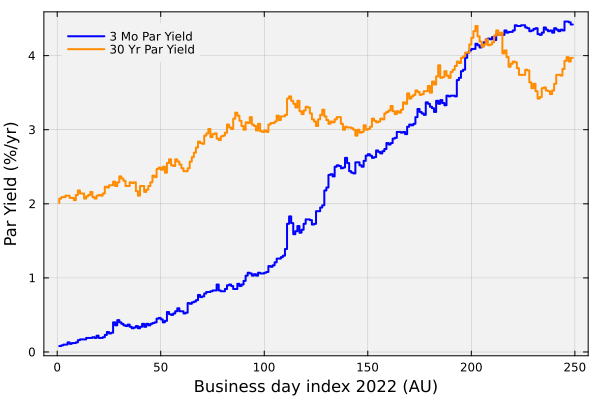

In [13]:
# Plot the short- and long-maturity par yields over the selected year.
let
    # Plot the short and long par yields by business-day row index.
    q = plot(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
    plot(q, indicator_array[:,1], lw=2, c=:blue, label="$(short_maturity_key) Par Yield", linetype=:steppre)
    plot!(indicator_array[:,2], lw=2, c=:darkorange, label="$(long_maturity_key) Par Yield", linetype=:steppre)
    xlabel!("Business day index $(year_of_data) (AU)", fontsize=18)
    ylabel!("Par Yield (%/yr)", fontsize=18)
end

#### Do we have a recession signal?
`Unhide` the code block to see how we visualized the `indicator_array::Array{Float64}` data for values of the maturity keys specified above.

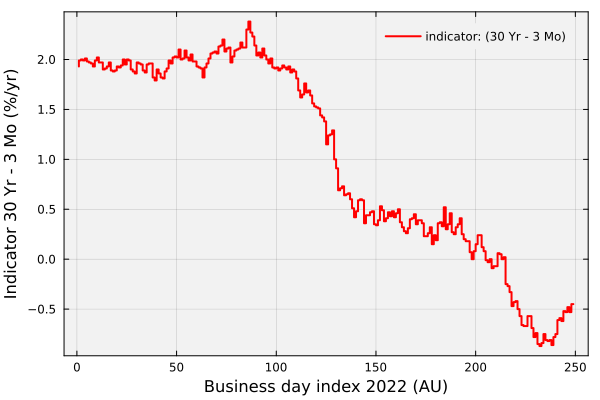

In [14]:
# Plot the long-minus-short par-yield spread over the selected year.
let
    # Plot the long-minus-short spread; negative values indicate curve inversion.
    q = plot(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
    plot(q, indicator_array[:,3], lw=2, c=:red, label="indicator: ($(long_maturity_key) - $(short_maturity_key))", linetype=:steppre)
    xlabel!("Business day index $(year_of_data) (AU)", fontsize=18)
    ylabel!("Indicator $(long_maturity_key) - $(short_maturity_key) (%/yr)", fontsize=18)
end

___

## Summary

This example organized Treasury rates by maturity, identified the par-yield curve, and constructed a long-minus-short maturity spread as a compact curve-shape indicator.

> __Key Takeaways:__
>
> * __A yield curve is maturity-indexed:__ Each point pairs a yield measure with a specific term to maturity on a common observation date. Comparing points across the maturity axis shows how the market prices short-term versus long-term lending.
> * __Curve labels identify different financial objects:__ Par yields, spot rates, and forward rates are related but are not interchangeable because they summarize different cash-flow and timing assumptions. Naming the curve type is the first step in any yield-curve calculation.
> * __A maturity spread summarizes one aspect of curve shape:__ A long-minus-short spread can identify inversion or steepness, but it is an indicator rather than a deterministic recession forecast. Its historical forecasting value depends on the maturity pair, the sampling convention, and the evaluation horizon.

Yield-curve interpretation is strongest when the rate definition, observation date, maturities, and limits of any derived signal are stated explicitly.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.